# Netflix Titles Dataset - Exploratory Data Analysis & Insights

## Objective
Explore Netflix content data to:
- Identify content trends
- Analyze country contributions
- Study genre popularity
- Extract year-wise growth patterns

Author: Sachin Singh


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


In [3]:
df = pd.read_csv("/kaggle/input/netflix-shows/netflix_titles.csv")

df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe(include="all")


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")


In [8]:
df["director"].fillna("Unknown", inplace=True)
df["cast"].fillna("Unknown", inplace=True)
df["country"].fillna("Unknown", inplace=True)
df["rating"].fillna("Unknown", inplace=True)


/tmp/ipykernel_55/4216550954.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Unknown", inplace=True)
/tmp/ipykernel_55/4216550954.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [9]:
df.drop_duplicates(inplace=True)


In [10]:
df["release_decade"] = (df["release_year"] // 10) * 10


In [11]:
df["is_movie"] = df["type"].apply(lambda x: 1 if x=="Movie" else 0)


In [12]:
df["year_added"] = df["date_added"].dt.year


In [13]:
genres = df["listed_in"].str.split(",").explode().str.strip()
top_genres = genres.value_counts().head(10)
top_genres


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [14]:
top_countries = df["country"].str.split(",").explode().str.strip().value_counts().head(5)
top_countries


country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
Name: count, dtype: int64

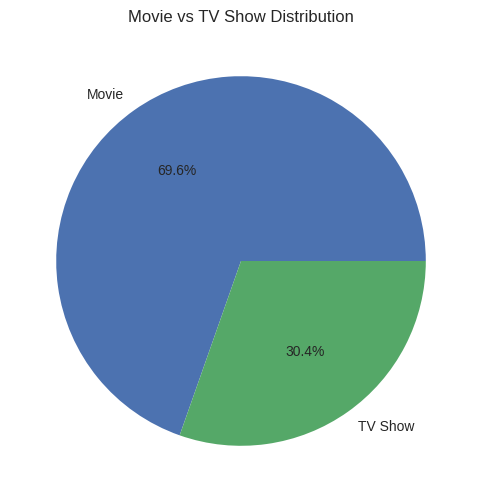

In [15]:
df["type"].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6,6))
plt.title("Movie vs TV Show Distribution")
plt.ylabel("")
plt.show()


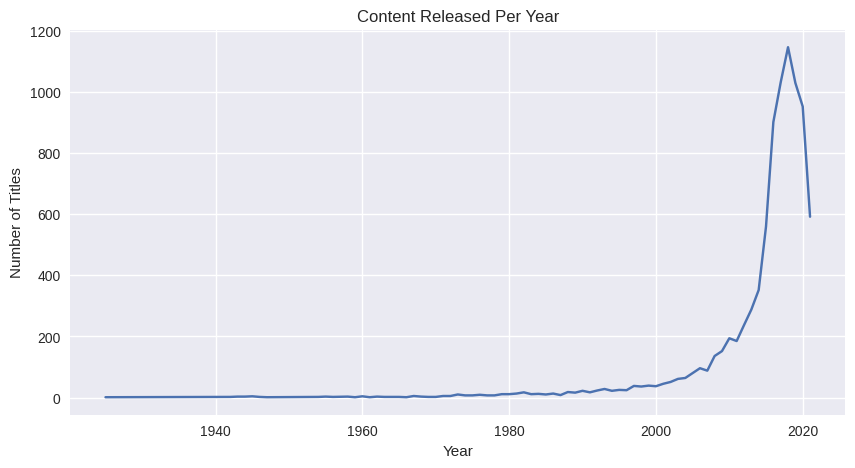

In [16]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Content Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()


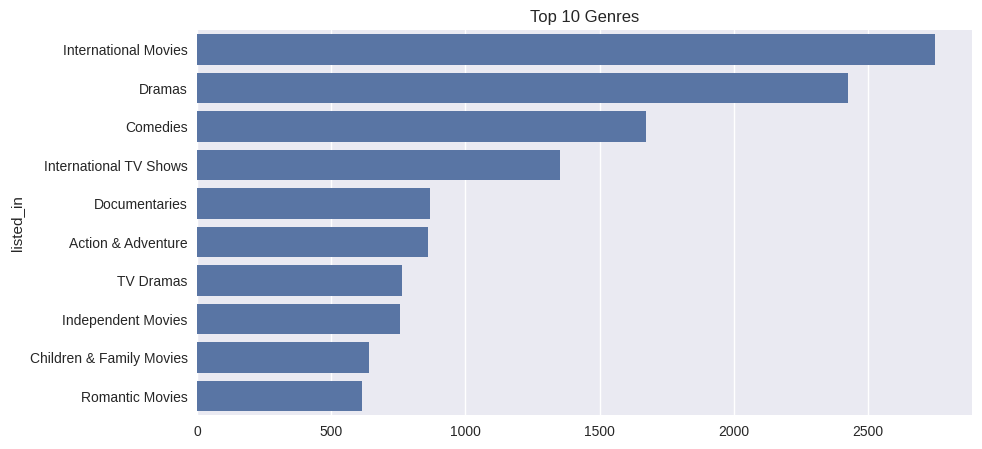

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.show()


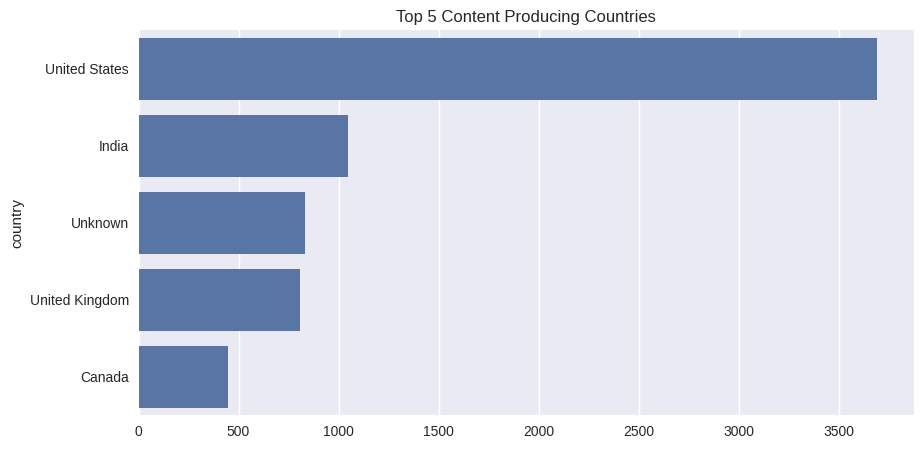

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 5 Content Producing Countries")
plt.show()


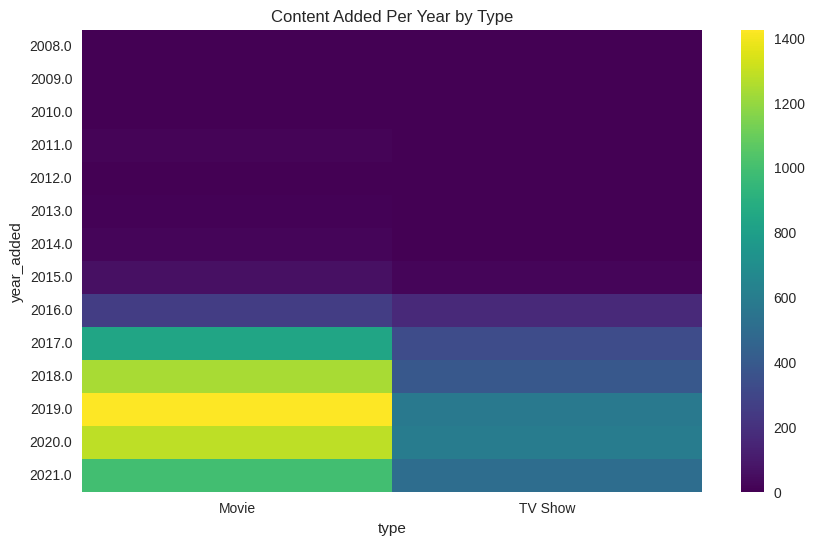

In [19]:
pivot = pd.crosstab(df["year_added"], df["type"])

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="viridis")
plt.title("Content Added Per Year by Type")
plt.show()


In [20]:
from sklearn.linear_model import LinearRegression

year_counts = df["release_year"].value_counts().sort_index()

X = year_counts.index.values.reshape(-1,1)
y = year_counts.values

model = LinearRegression()
model.fit(X,y)

future_years = np.array([2024,2025]).reshape(-1,1)
predictions = model.predict(future_years)

predictions


array([397.2485691 , 404.13235182])

# Key Insights

1. Movies dominate Netflix catalog (~70%).
2. Content production increased significantly after 2015.
3. USA and India are top content-producing countries.
4. Drama and International Movies are most popular genres.
5. TV Shows have shown steady growth in recent years.
6. Based on trend prediction, content volume is expected to continue increasing.


In [21]:
df.shape


(8807, 15)